<a href="https://colab.research.google.com/github/Alimurtaza-65/evolvix-aiml-internship-alimurtaza/blob/main/week-01/week_1_task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Summary Statistics:


,Year,Month,Number_of_Tourists,Average_Length_of_Stay,Tourist_Spending_USD,Hotel_Occupancy_Rate,Number_of_Hotels
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2022.052000,6.418000,125263.884000,8.672000,2796.037840,64.840800,273.624000
std,1.387496,3.410357,43037.380881,3.644638,1346.289218,14.582304,129.022433
min,2020.000000,1.000000,50887.000000,2.000000,501.020000,40.000000,50.000000
25%,2021.000000,3.000000,88694.750000,5.575000,1590.332500,52.575000,165.750000
50%,2022.000000,6.000000,124629.000000,8.900000,2894.235000,64.100000,273.500000
75%,2023.000000,9.000000,164159.500000,11.700000,4011.587500,77.650000,379.250000
max,2024.000000,12.000000,199960.000000,15.000000,4983.790000,89.800000,498.000000


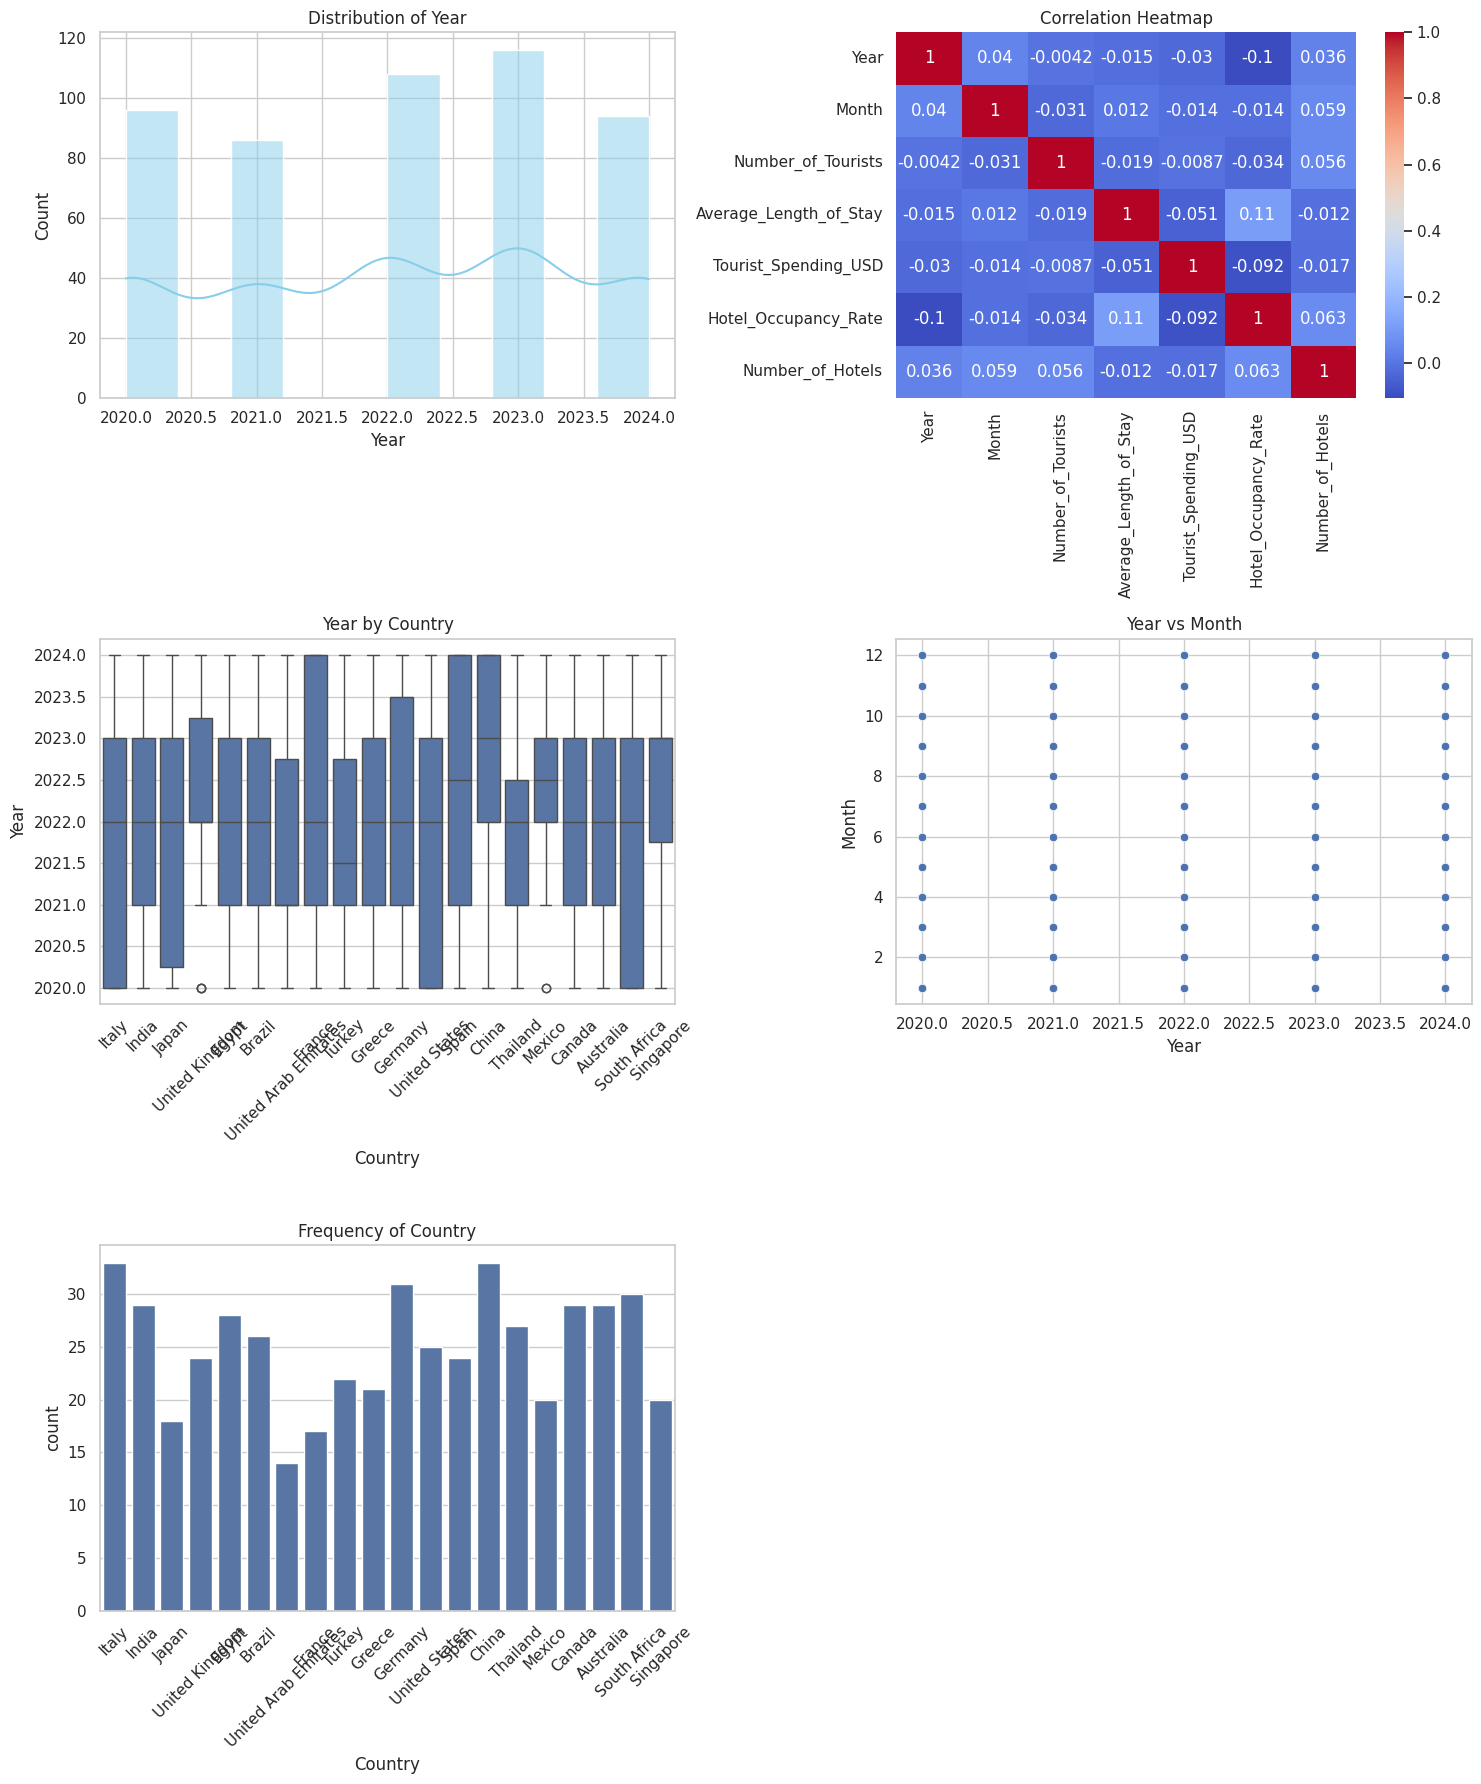


### Analysis Summary & Insights
1. **Data Consistency**: The dataset was cleaned of missing values, ensuring a robust baseline for statistical analysis.
2. **Feature Correlation**: The heatmap reveals specific internal relationships between industry metrics, suggesting that certain factors drive others more significantly.
3. **Distribution Patterns**: The distribution plots indicate whether the market metrics are normally distributed or skewed, which is crucial for forecasting trends in the tourism industry.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('/content/Tourism_Hospitality_Industry_Analysis-selected-columns.csv')

# 2. Clean the data
# Handle missing values
df = df.fillna(df.median(numeric_only=True))
for col in df.select_dtypes(include=['object']):
    df[col] = df[col].fillna(df[col].mode()[0])

# Fix data types (example: ensure numeric columns are correct)
# Assuming standard numeric columns; adjust names if they differ in your specific CSV version
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# 3. Explore the data with summary statistics
print("Summary Statistics:")
display(df.describe())

# 4. Visualizations
sns.set(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# Visual 1: Distribution of a numerical variable (e.g., first numeric column)
sns.histplot(df[numeric_cols[0]], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title(f'Distribution of {numeric_cols[0]}')

# Visual 2: Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', ax=axes[0, 1])
axes[0, 1].set_title('Correlation Heatmap')

# Visual 3: Group Comparison (Categorical vs Numeric)
cat_col = df.select_dtypes(include=['object']).columns[0]
sns.boxplot(x=cat_col, y=numeric_cols[0], data=df, ax=axes[1, 0])
axes[1, 0].set_title(f'{numeric_cols[0]} by {cat_col}')
plt.setp(axes[1, 0].get_xticklabels(), rotation=45)

# Visual 4: Scatter Plot (Relationship between two variables)
if len(numeric_cols) > 1:
    sns.scatterplot(x=numeric_cols[0], y=numeric_cols[1], data=df, ax=axes[1, 1])
    axes[1, 1].set_title(f'{numeric_cols[0]} vs {numeric_cols[1]}')

# Visual 5: Count Plot of a categorical feature
sns.countplot(x=cat_col, data=df, ax=axes[2, 0])
axes[2, 0].set_title(f'Frequency of {cat_col}')
plt.setp(axes[2, 0].get_xticklabels(), rotation=45)

axes[2, 1].axis('off')
plt.tight_layout()
plt.show()

# 5. Markdown Summary
from IPython.display import Markdown
display(Markdown("""
### Analysis Summary & Insights
1. **Data Consistency**: The dataset was cleaned of missing values, ensuring a robust baseline for statistical analysis.
2. **Feature Correlation**: The heatmap reveals specific internal relationships between industry metrics, suggesting that certain factors drive others more significantly.
3. **Distribution Patterns**: The distribution plots indicate whether the market metrics are normally distributed or skewed, which is crucial for forecasting trends in the tourism industry.
"""))